# Quality toolbox

In [1]:
# Import library needed
#import functions
import numpy as np
import matplotlib.pyplot as plt

from NEUREQUA import *


from NEUREQUA import cognitive_module as cog 
from NEUREQUA import quality_module as quality

## Load data and parameters

In [2]:
# Parameters of the session you analyze

# Name or number of the subject you analyze
sub = 'sub-127'
# Name of the session you analyze
sess = 'sess-3'

In [3]:
# Path to data - This is the only thing you have to change to run the script


# Path where your micro data are stored (.dat, .medd, .nsX, .ncs)
dataFolder=r'F:/Neurequa/Database/sub-127/erp_ncs/'
#dataFolder=r'F:/Screening/database/sub-97/sess-1/ncs/' 

# Path where you want to store figures and results
saveFolder=r'F:/Neurequa/Database/sub-127/Quality_Metrics/'

# path to excel file for the RMS tracking, only one excel is used per patient, all RMS data for the SEEG will be trancked on a single file

trackingtbl1 =r'C:/Users/dornier/PhD/Article/NeuReQua/Analyses/Sub-127/'
trackingtbl =r'C:/Users/dornier/PhD/Article/NeuReQua/Analyses/Sub-127/tracking_table.xlsx'


In [6]:
# Load data 
# Give the path folder where the files of micro-electrodes are stored
raw_data, data = quality.load_raw_data(dataFolder,dtype='ncs',length=5,pattern2exclude='_sub.ncs')


Checking files in F:\Neurequa\Database\sub-101\ncs
Ignoring .ncs files:



ParserError: Unknown string format: File was

In [5]:
# Determine parameters from the recording
sr = int(raw_data.info['sfreq'])
print("Your recording has a sampling rate of: " + str(sr) +" Hz")

Your recording has a sampling rate of: 30000 Hz


In [6]:
duration_min  = int(raw_data.__len__()/sr/60)

print("L'enregistrement a duré : "+str(duration_min)+" minutes")

L'enregistrement a duré : 5 minutes


In [7]:
# Display the name of your electrodes

chRegions = np.array(raw_data.ch_names)
print(chRegions)

['c1' 'c2' 'c3' 'c4' 'c5' 'c6' 'c7' 'c8' 'c9' 'c10' 'c11' 'c12']


In [8]:
# Re-order channels and data if there is more than two tetrode on a shaft
chRegions, data = quality.reorder_data(chRegions,data)


print(chRegions)

['c1' 'c2' 'c3' 'c4' 'c5' 'c6' 'c7' 'c8' 'c9' 'c10' 'c11' 'c12']


In [9]:
# Prepare the tracking file

quality.tblprep(trackingtbl1,chRegions,sub,sess)

## Quality analysis of the signal

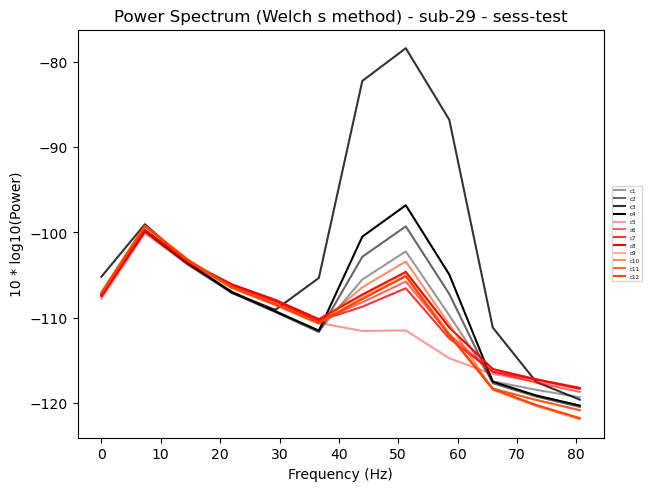

In [10]:
# Get the power spectrum of each channel 
p_welch = quality.p_welch(data,chRegions,sub,sess,sr,sr_down=1,fr_low=1,fr_high=90,saveFolder=saveFolder,probe_type='Dixi')

In [11]:
# Get the level of noise of the recording for each channel (not displayed in the notebook)
quality.plot_noise(data,sr,chRegions,saveFolder)


[np.float64(1.4107346477542566e-05),
 np.float64(1.4650109822707857e-05),
 np.float64(3.655899183879271e-05),
 np.float64(1.658646293020447e-05),
 np.float64(1.361742976855233e-05),
 np.float64(1.3191424717391591e-05),
 np.float64(1.3235169936709547e-05),
 np.float64(1.3237222809245851e-05),
 np.float64(1.352505629357089e-05),
 np.float64(1.3115910227179386e-05),
 np.float64(1.3676288200101427e-05),
 np.float64(1.341227716833405e-05)]

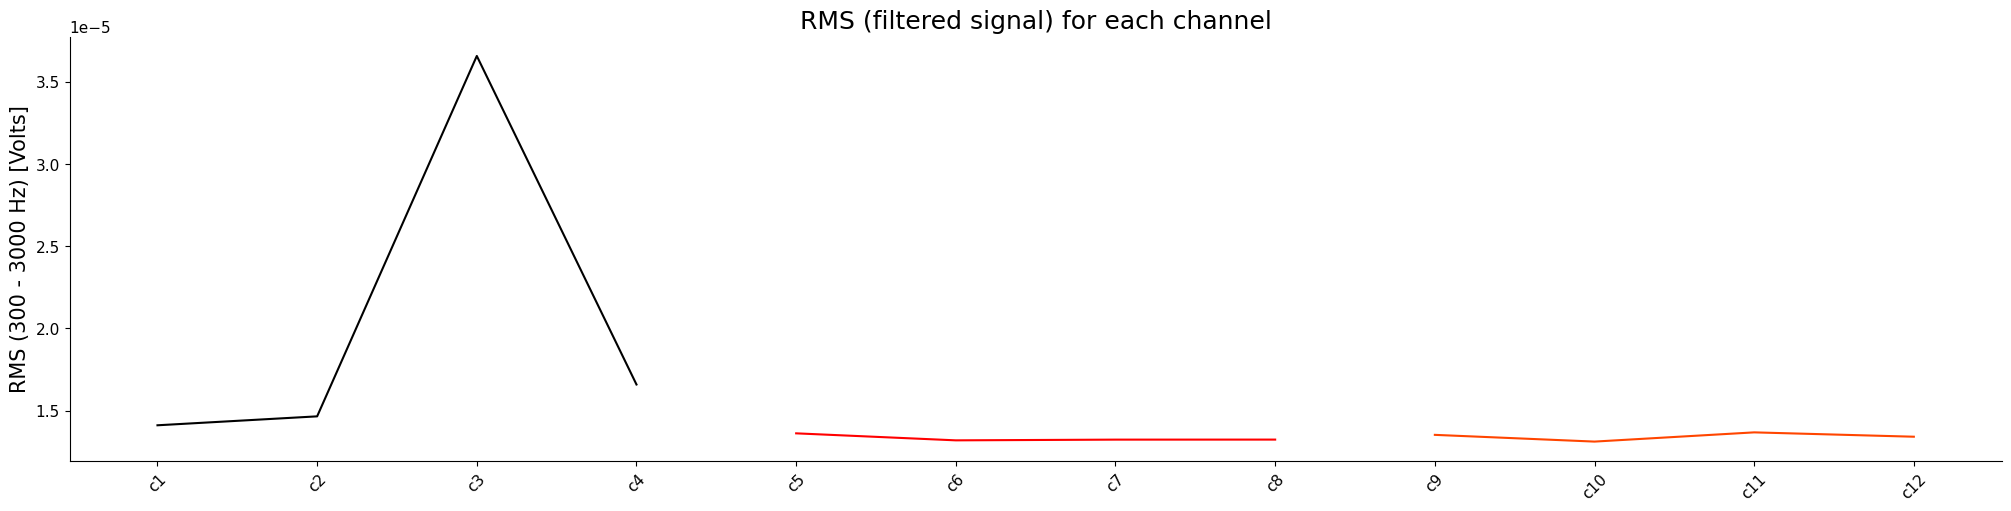

In [12]:
# Compute RMS on filtered signal
quality.rms_signal_filtered(data,trackingtbl,chRegions,sub,sess,fr_low=300,fr_high=3000,sr=sr,saveFolder=saveFolder) 

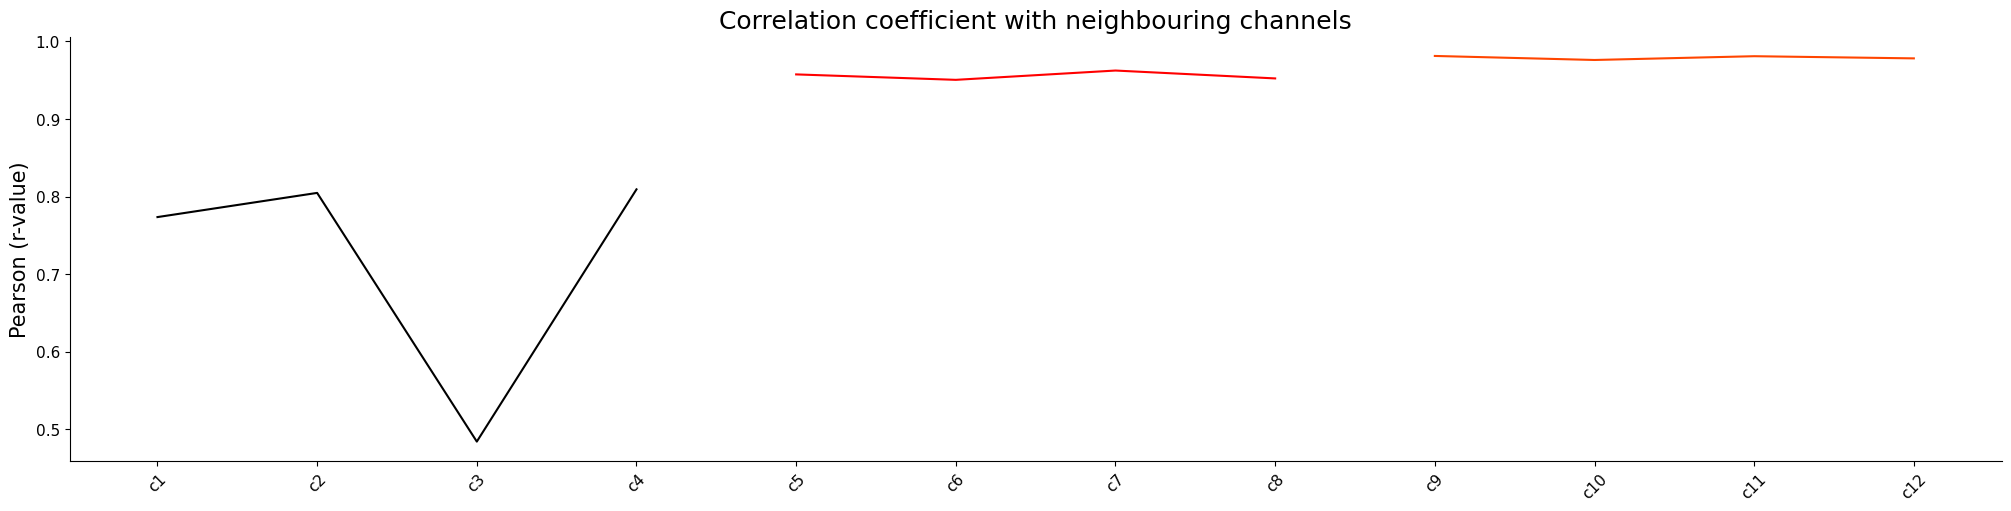

In [13]:
# Compute correlation between neighbouring channels

correlation = quality.correlation_coefficient(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

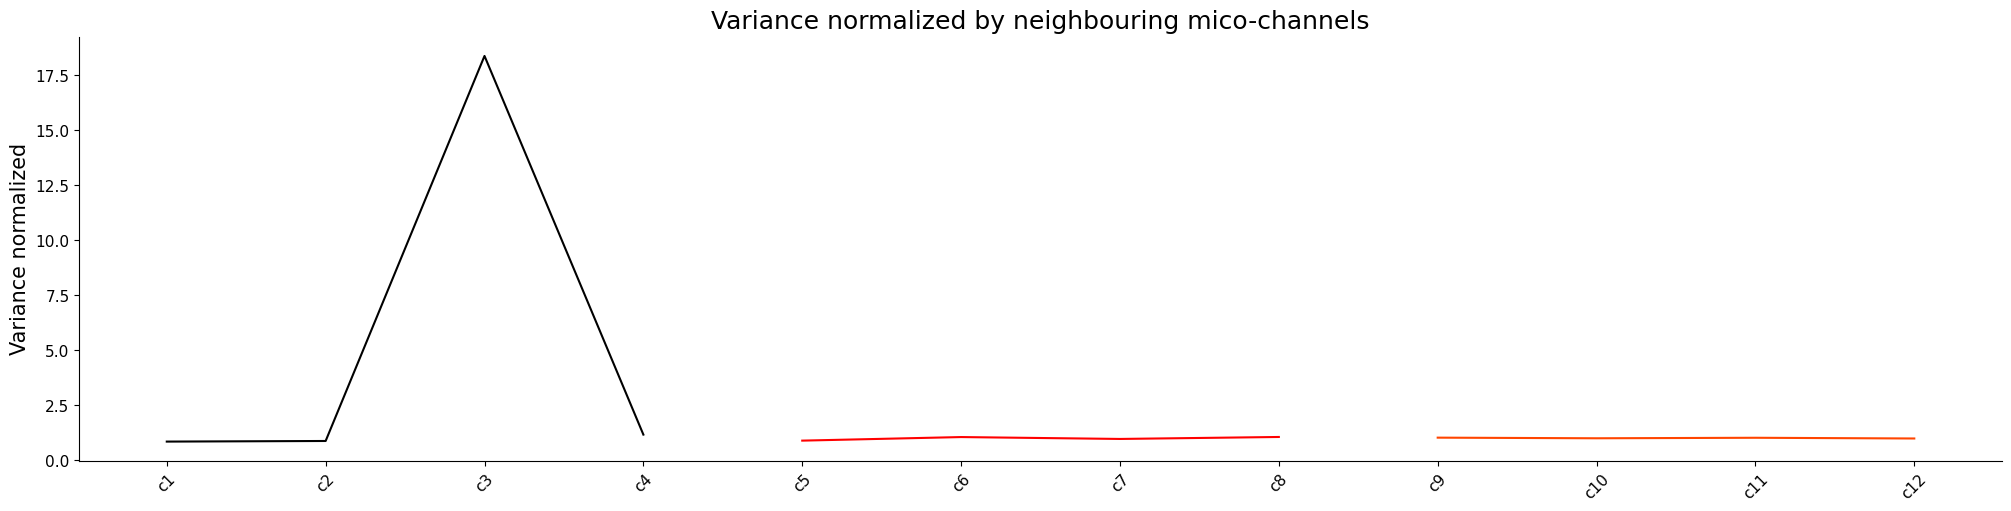

In [14]:
# Compute variance normalized by variance of neighbouring channels
quality.variance_normalized(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

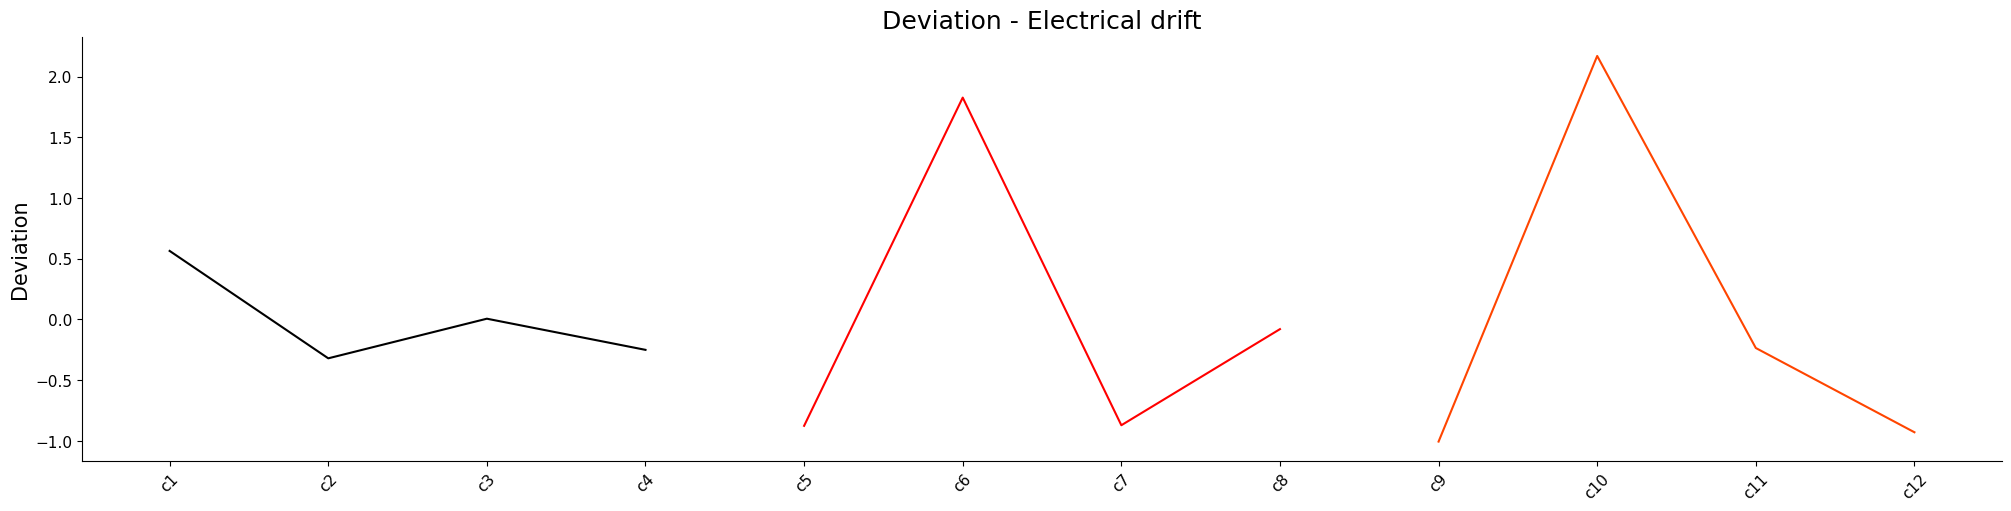

In [15]:
quality.deviation(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

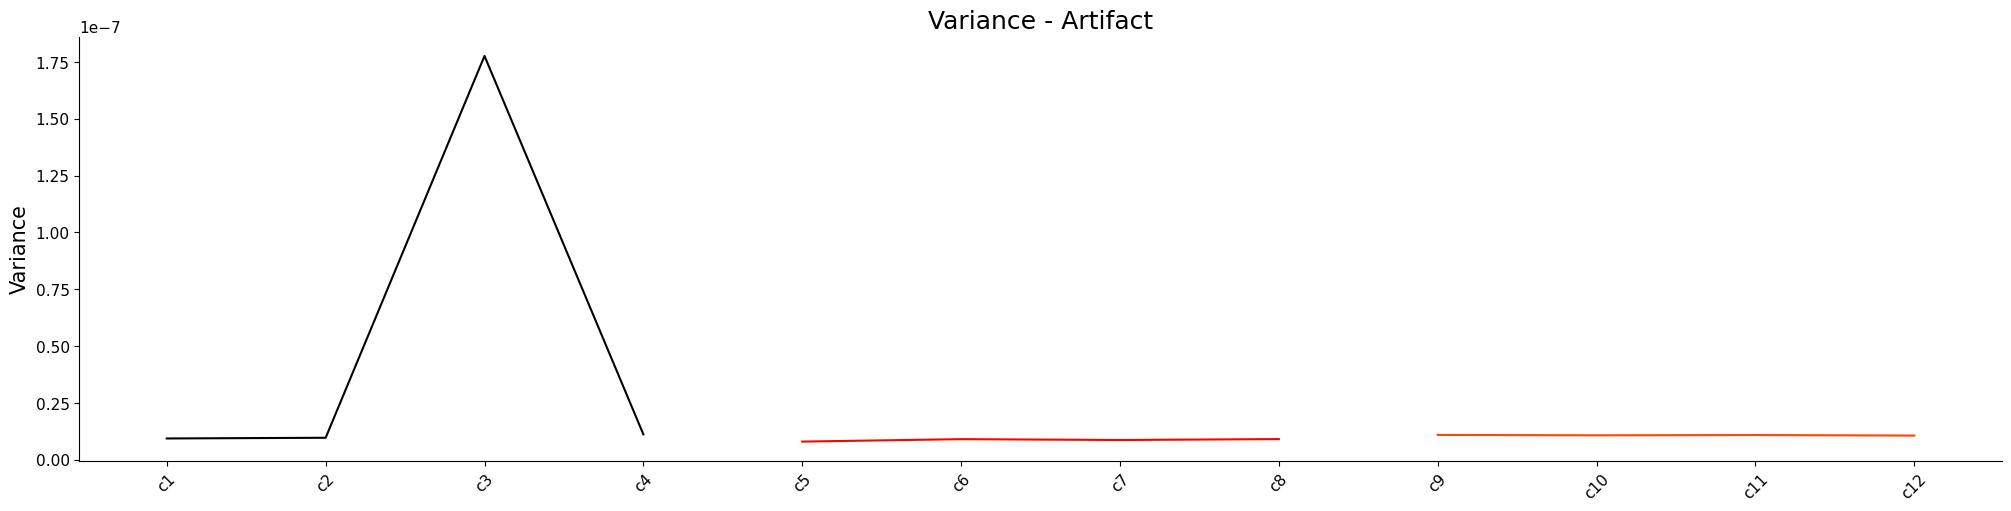

In [16]:
quality.variance(data,chRegions,saveFolder,trackingtbl,sub,sess)

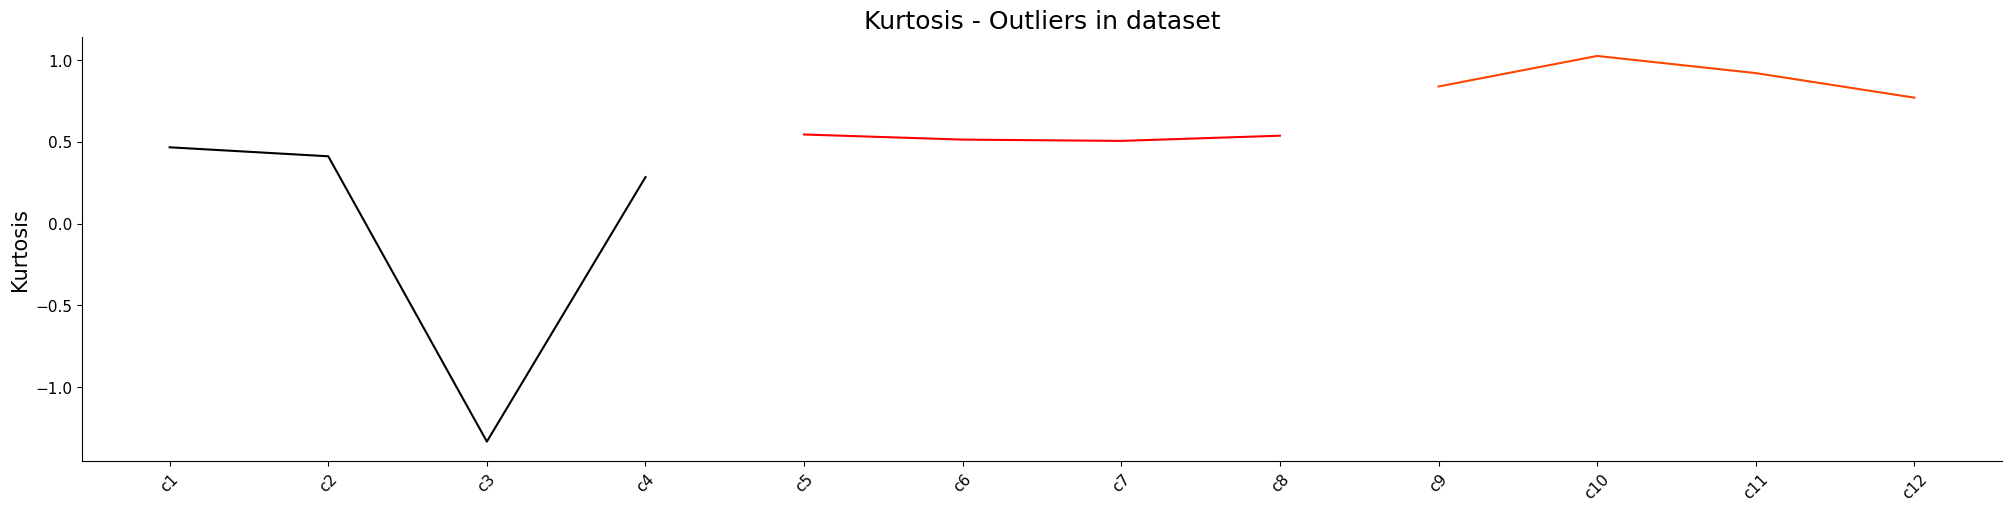

In [17]:
quality.kurtosis(data,chRegions,saveFolder,trackingtbl,sub,sess)

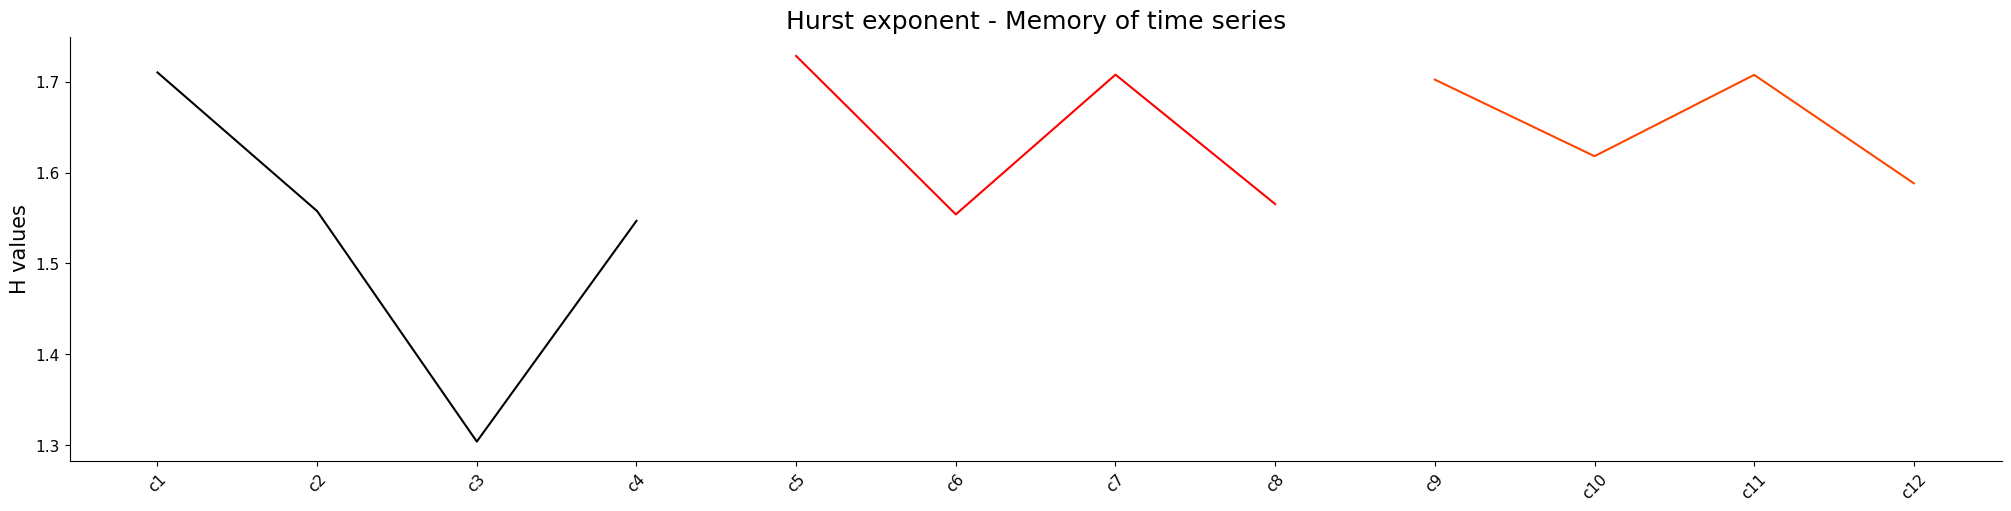

In [18]:
quality.hurst_component(data,chRegions,saveFolder,trackingtbl,sub,sess)

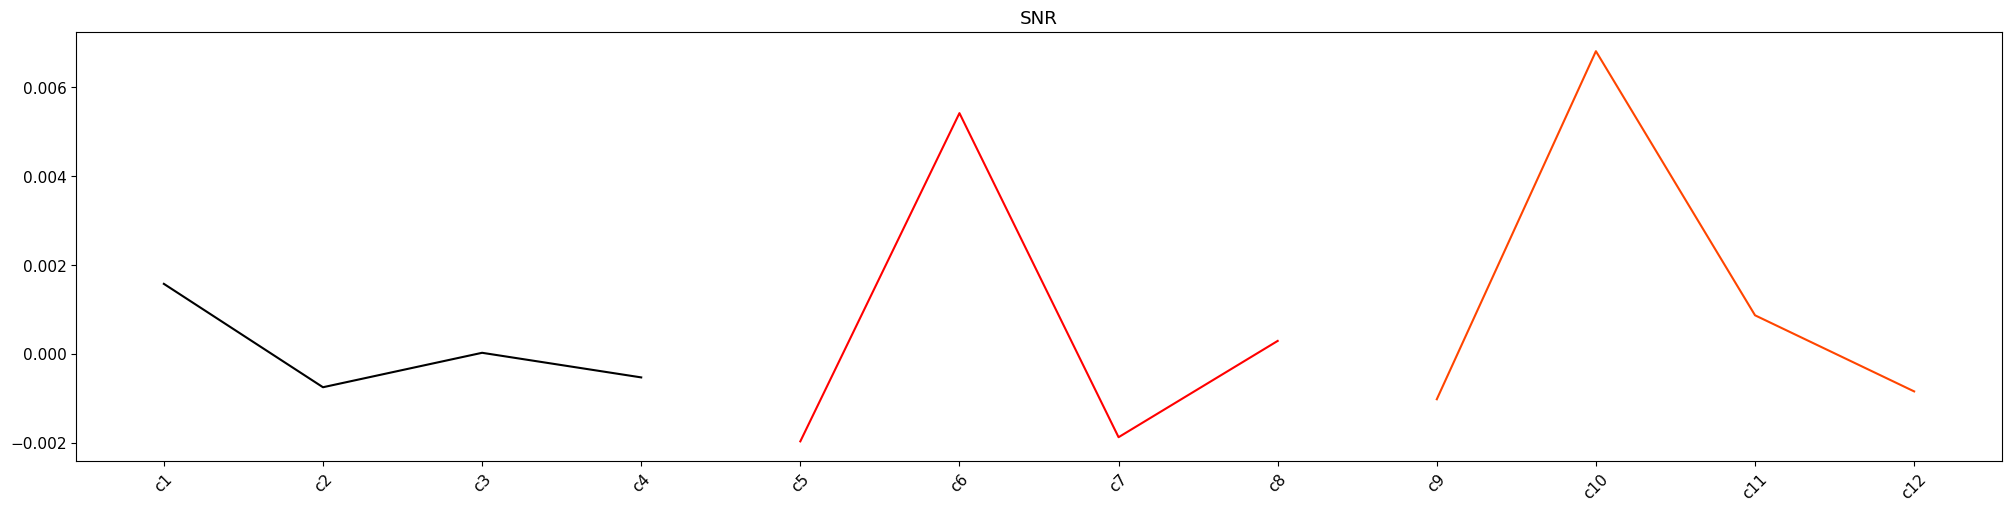

In [19]:
SNR = quality.signaltonoise(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [20]:
# Test on artefacts
from NEUREQUA import artefact_detections

test = list()

for iTetrode in range(int(data.shape[0]/4)):
    num_canalTetrode = (iTetrode*4,iTetrode*4+1,iTetrode*4+2,iTetrode*4+3)

    test.append(num_canalTetrode)

tetInds = test 

# Movement artefacts
badWins_movement = artefact_detections.detect_movement_artifacts(chTraces=data,chGoodInds=list(range(len(chRegions))),
                                                                tetInds=tetInds,verbose=False,SR=32768)


# Detect subtle artefacts
badWins_subtle = artefact_detections.detect_subtle_artifacts(chTraces=data,chGoodInds=np.array(list(range(len(chRegions)))),
                                                            tetInds= tetInds,chRegs=chRegions,SR=32768,verbose=False)

# Step 3: Merge detected windows using intersection
badWins_final = artefact_detections.get_timeWinsIntersect(badWins_movement, badWins_subtle, data.shape[1])


# Step 4: Print percentage of artefacted signal
artefact_detections.ratio_artefact(data,badWins_final,trackingtbl,sub,sess)

Your recording contains: 0.007299999188888979 % of artefacts


# Cognitive analyses of experiment

In [4]:
# Step 1 - Create the file with raw data
raw, metadata = cog.load_neuralynx_micro(dataFolder,sub,sess)

Found 56 .ncs file(s) in 'F:/Neurequa/Database/sub-127/erp_ncs/'
Excluding channels matching pattern: '*_sub'
  → 0 macrocontact channel(s) excluded
  → 56 microwire channel(s) retained
File already exist

── Recording summary ──────────────────────────────
  Channels   : 56
  Samp. rate : 32768 Hz
  Duration   : 2499.7 s (41.66 min)
  Samples    : 81,909,466
  Data shape : (56, 81909466)  (channels × samples)
  Channel labels:
    • db1
    • db2
    • db3
    • db4
    • db5
    • db6
    • db7
    • db8
    • dtp1
    • dtp10
    • dtp11
    • dtp12
    • dtp2
    • dtp3
    • dtp4
    • dtp5
    • dtp6
    • dtp7
    • dtp8
    • dtp9
    • vb1
    • vb2
    • vb3
    • vb4
    • vb5
    • vb6
    • vb7
    • vb8
    • vgc1
    • vgc10
    • vgc11
    • vgc12
    • vgc2
    • vgc3
    • vgc4
    • vgc5
    • vgc6
    • vgc7
    • vgc8
    • vgc9
    • vof1
    • vof2
    • vof3
    • vof4
    • vof5
    • vof6
    • vof7
    • vof8
    • vtp1
    • vtp2
    • vtp3
    • vtp4
    • 

c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:120: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID ea1efbb1-18e4-46d9-947a-72a17526a4cc
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:134: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2023/03/28 11:40:20
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\

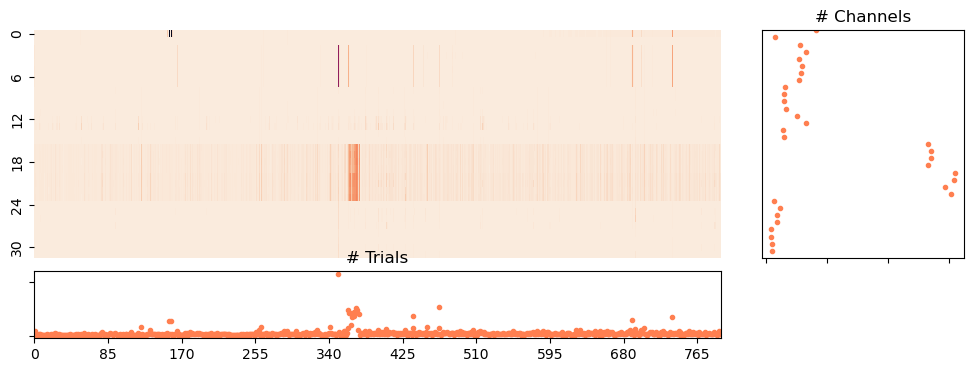

In [5]:
cog.plot_artefact_map(dataFolder,sub,sess)

In [ ]:
cog.plot_erp(dataFolder,metadata,sub,sess,mua=True)

c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:168: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:253: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:253: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID 07fc3218-59b6-4d67-801b-41d2ed3e0869
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:182: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2025/07/03 09:36:25
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\